# Tic-Tac-Toe Q-Learning Agent

### Author: Diego Salort Antón
Implementation of a Reinforcement Learning agent using **Tabular Q-Learning** with **Symmetry Reduction** to optimize training efficiency.

In [ ]:
# Para aleatoriedad
import random
# Para interfaz del juego
import tkinter as tk
from tkinter import messagebox
# Para gráficas de estadísticas del entrenamiento
import matplotlib.pyplot as plt

## 1. Problema planteado
El objetivo de este laboratorio es desarrollar, utilizando **aprendizaje por refuerzo** y **Q-learning**, un sistema inteligente capaz de jugar al popular _Tres en Raya_ (en inglés, _Tic Tac Toe_).
Se busca desarrollar un agente experto en este clásico juego cuya habilidad varíe dependiendo del número de episodios de entrenamiento, llegando incluso a la invencibilidad total (solo podremos empatar o perder contra el agente).
Se utilizan recursos de programación orientada a objetos para facilitar la implementación y diferenciar entre la lógica del propio juego, la del agente, la interfaz gráfica y la de consola.

En este juego, la introducción de un oponente que juegue contra nuestro agente conlleva a que un mismo estado del tablero alcanzado en distintas partidas pueda producir resultados diferentes dependiendo de la decisión del oponente. Por ello mismo, es un entorno no determinista, dados el estado actual y la acción, no es posible determinar unívocamente el estado al que el entorno transita.

Este programa ofrece la posibilidad de jugar contra el agente entrenado por interfaz gráfica y por consola. Si se desea jugar con interfaz gráfica, es necesario instalar la librería `tkinter` y su módulo `messagebox`. La configuración para elegir interfaz (`gui`), así como si empezar la partida primero o no (`start_player`); y jugar usando X o O (`user_symbol`), se encuentra en la función `main()`.

#### **Nota: La librería tkinter no es compatible con Google Colab y dará error. En entornos como Colab solo se puede usar la interfaz por consola.**

## 2. Lógica de juego
La clase `TicTacToe` contiene la lógica del juego. Representaremos un tablero de 3x3 como una tupla de 9 posiciones (índice 0 a 8). Las posiciones del tablero son:
<p style="text-align:center">
0 | 1 | 2<br>
3 | 4 | 5<br>
6 | 7 | 8
</p>


El tres en raya es un juego por turnos, donde se enfrenta un jugador que empieza la partida (_player_1_) contra otro que la continúa (_player_2_). El usuario elegirá una configuración de juego en la función main y jugará contra el agente entrenado.

El contenido de la tupla que representa un tablero puede ser:
- **1**: representa una ficha del _player_1_ en el tablero.
- **2**: representa un ficha del _player_2_ en el tablero.
- **0**: representa una casilla vacía, sin ficha.

Por ejemplo, la tupla (1, 2, 1, 2, 2, 1, 1, 2, 0), suponiendo que el usuario (humano) comienza la partida (1) y juega con X, representa el siguiente tablero:
<p style="text-align:center">
X | 0 | X<br>
0 | 0 | X<br>
X | 0 | -
</p>

In [68]:
class TicTacToe:
    def __init__(self):
        self.board = [0] * 9 # Inicializado a 0's (vacío)
        self.winner = None # 1 si gana player 1, 2 si gana player 2, none en otro caso

    def reset(self):
        """
        Restablece el tablero (lo vacía) y el ganador.
        """
        self.board = [0] * 9
        self.winner = None
        return tuple(self.board)

    def check_winner(self):
        """
        Comprueba si hay algún ganador
        """
        if self.winner:
            return self.winner

        # Combinaciones de casillas ganadoras en un tablero 3x3
        win_combinations = [
            (0, 1, 2), (3, 4, 5), (6, 7, 8),  # Filas
            (0, 3, 6), (1, 4, 7), (2, 5, 8),  # Columnas
            (0, 4, 8),                        # Diagonal Dr-Izq
            (2, 4, 6)                         # Diagonal Izq-Dr
        ]

        # Comprobamos si en las casillas de una misma combinación se encuentra la misma pieza (1 o 2). Si es así, hay ganador
        for a, b, c in win_combinations:
            if self.board[a] == self.board[b] == self.board[c] != 0:
                self.winner = self.board[a]
                return self.winner
        return None

    def is_game_over(self):
        """
        El juego termina si...:
            - Hay un ganador
            - El tablero se ha quedado sin espacios (0) (empate)
        """
        if self.winner is not None:
            return True

        # Si encontramos un hueco en el tablero, la partida no ha terminado
        if 0 in self.board:
            return False

        return True # Empate

    def new_piece(self, position, player):
        """
        position es un número del 0 al 8 que representa la posición del tablero donde colocar la ficha.
            0 1 2
            3 4 5
            6 7 8

          player es la ficha que se coloca: 1 si es player_1, 2 si es player_2
        """
        if self.board[position] == 0: # La casilla debe estar vacía
            self.board[position] = player
            self.check_winner()
            return True

        return False # Movimiento inválido (En la casilla había ya una pieza)

    def get_possible_moves(self):
        """
        Devuelve una lista con las casillas vacías, es decir, aquellas en donde se puede poner una ficha.
        """
        return [i for i, piece in enumerate(self.board) if piece == 0]

    # Convierte un board (lista) en formato tuple
    def get_board(self):
        return tuple(self.board)

## 3. Agente (La IA)
La clase `Agent` representa el sistema inteligente a desarrollar, que será entrenado para aprender a jugar a este clásico juego (explicado más adelante).
### 3.1. Q-Learning
Nuestro agente aprenderá y actualizará su _tabla Q_ durante una fase de entrenamiento (explicada más adelante), para luego enfrentarse a un oponente humano.
Al estar ante un entorno no determinista y con el fin de conseguir una convergencia gradual, haremos uso de la siguiente ecuación:
$$\hat{Q}_n(s, a) = \hat{Q}_{n-1}(s, a) + \alpha_n \cdot [r_n + \gamma \cdot \max \hat{Q}(s', a') - \hat{Q}_{n-1}(s, a)]$$

- $\alpha$ representa la tasa de aprendizaje. Valores cercanos a 1 (entornos deterministas) suponen una mayor frecuencia de actualización de los valores de la tabla Q; en cambio, valores cercanos al 0 dan más peso al valor actual frente al nuevo. En nuestro caso, no podemos mantener un $\alpha$ constante y alto debido a que cuando el agente aprenda estrategias buenas, estas podrían llegar a ser olvidadas; tampoco puede ser constantemente bajo porque al inicio le costaría mucho aprender nuevas estrategias. Por este motivo, implementamos un $\alpha$ dinámico, que varía según la fórmula:
  $$\alpha_n = \frac{1}{1 + \#visitas(s, a)}$$
  - \#visitas(s, a): Número de veces que, tras visitar s, se ha realizado a.
De este modo, al inicio del entrenamiento y cuando un tablero no se haya visitado mucho, será capaz de aprender; y en etapas avanzadas, donde ya se ha estudiado varias veces este tablero, será capaz de mantener las estrategias aprendidas e incluso corregirlas, asegurando convergencia. $\alpha$ siempre será mayor o igual a `self.min_alpha = 0.1`
- $\gamma$ representa el factor de descuento. Si la fijamos cerca de 1, damos más peso a las recompensas futuras. Si lo reducimos hacia cero, hacemos más hincapié en la recompensa inmediata del siguiente movimiento. Como al agente le debe interesar terminar ganando la partida, lo adecuado es un valor de $\gamma$ cercano a 1. Nosotros le asignamos `self.gamma = 0.95`. De este modo, el agente puede construir estrategias ganadoras desde el primer momento.
- **$r_n$** es la recompensa obtenida por realizar la acción (poner una pieza) _a_ en el estado (tablero) _s_. Nótese que solo se otorga una recompensa al ganar (+100), perder (-100) o empatar (+20). Los estados intermedios producen una recompensa de 0 (recompensas dispersas).
- Q(s, a) representa el valor Q asociado para el estado (tablero) _s_ y la acción (poner una ficha) _a_.
- max Q(s', a') representa el mayor valor Q obtenible de entre todos los posibles estados siguientes.

### 3.2. Mecanismos de generalización
La tabla Q es un diccionario con clave un estado del tablero, y valor otro diccionario con clave las posibles casillas en las que podemos colocar una ficha, y su valor, Q. Almacenar una entrada en el diccionario por cada estado posible en el tablero resultaría en una tabla Q ineficiente tanto en espacio como en tiempo. Por este motivo, se van a clasificar los tableros que compartan características entre sí, y estas características van a ser su simetría.

Podemos observar que, si tenemos un tablero Z y otro Z', si se cumple que Z' es una rotación (90º, 180º, 270º) de Z, Z y Z' son, en esencia, el mismo tablero. Lo mismo ocurre con las reflexiones (espejos) de cada tablero. Por ello mismo, introducimos el concepto de tablero (estado) normalizado, que actúa como representante de todas estas rotaciones y espejos. El tablero normalizado será la mínima tupla (que representa a cada tablero) en orden lexicográfico de entre todas las rotaciones y respectivos espejos (además del tablero original y su propio espejo).

Cuando transformamos un tablero en su tablero normalizado, también debemos proporcionar una forma de mapear cada casilla del tablero original al nuevo tablero normalizado, para saber cuál es la nueva casilla en la que le corresponde poner ficha en este tablero para que el movimiento siga siendo el mismo. Por todo esto y para hacerlo de un modo eficiente, utilizamos la tabla `SYMMETRIES_TABLE`. La función encargada de calcular el tablero normalizado y su correspondiente mapa (para saber las correspondencias entre las casillas del tablero original y las del nuevo) es `get_normalized_state_and_map()`.

### 3.3. Aceleración del proceso de aprendizaje: actualización hacia atrás
En este tres en raya, solo se otorga un valor Q al finalizar una partida. Este puede ser:
- `REWARD_WIN = +100`, si se gana la partida
- `REWARD_LOSS = -100`, si se pierde la partida
- `REWARD_DRAW = +20`, si hay empate, para incentivar estrategias defensivas en caso de que no se pueda ganar.

Sin backtracking, cada episodio produciría una única actualización de la función Q, lo que provocaría una convergencia muy lenta (tardaría mucho en aprender, solo se actualizaría el valor de una entrada de la Q-table por episodio).

Como solución a este problema, y con el fin de conseguir una convergencia más rápida, cada vez que un episodio finaliza se aplica una actualización hacia atrás (_backtracking_). El agente lleva un historial (`self.history`), que contiene todos los pares _estado - acción_ visitados hasta llegar al fin del episodio. Cada par _estado - acción_ por el que se pasa se va guardando en el historial gracias a la función `save_record()`.

Al finalizar un episodio, se ejecuta `update_backtracking()`, encargada de retroceder desde el final hasta el principio, actualizando cada valor Q según la fórmula del Q-learning mostrada anteriormente. También se resetea el historial (`self.history = []`) para el siguiente episodio.

Con este método, conseguimos que un episodio de longitud _n_ se convierta en _n_ episodios, acelerando el proceso de aprendizaje considerablemente.

### 3.4. Mecanismos de selección de acciones: Enfoque _epsilon-greedy-decreasing_
A la hora de seleccionar una acción a realizar en un estado determinado, es fundamental ponderar de manera adecuada la explotación de lo conocido y la exploración de lo que está por conocer. Por ello, aplicamos el enfoque _epsilon-greedy_:
- Se establece un valor $\epsilon$ entre 0 y 1, y se genera otro número aleatorio entre 0 y 1 (llamémosle z). De este modo:
    - Si z < $\epsilon$, se selecciona una acción aleatoria (exploración)
    - Si z >= $\epsilon$, se selecciona la acción de mayor valor Q (explotación). Si más de una acción tiene el valor Q máximo, se elegirá aleatoriamente de entre estas acciones.

También se aplicó un enfoque _epsilon-decreasing_: Ajustamos $\epsilon$ dinámicamente, manteniéndolo cercano a 1 al comienzo del aprendizaje, animándole a explorar nuevas estrategias; y disminuyéndolo progresivamente, para fomentar la explotación de las estrategias conocidas. Para conseguir este decremento, multiplicamos $\epsilon$ por una constante `self.decrease_epsilon` al finalizar cada episodio (función `reduce_epsilon`). Durante el entrenamiento, $\epsilon$ valdrá como mínimo `self.min_epsilon = 0.01`. Cuando la IA está entrenada y juega contra el humano, $\epsilon$ = 0, para poder explotar todas sus estrategias aprendidas. No tendría sentido un epsilon mayor, ya que implicaría un porcentaje de elecciones totalmente aleatorias.

In [69]:
class Agent:

    # Recompensas otorgadas durante el entrenamiento
    REWARD_WIN = +100
    REWARD_LOSS = -100
    REWARD_DRAW = +20

    # Para las simetrías: Tabla con tuplas de la forma (nuevo_tablero, mapeo de las casillas del tablero original al nuevo tablero)
    # El mapeo de las casillas nos indica dónde se encuentra la casilla sobre la que se iba a poner una ficha en este nuevo tablero.
    # Estático, ya que lo compartirán los agentes durante el entrenamiento
    SYMMETRIES_TABLE = [
        ((0, 1, 2, 3, 4, 5, 6, 7, 8), (0, 1, 2, 3, 4, 5, 6, 7, 8)), # 0º
        ((6, 3, 0, 7, 4, 1, 8, 5, 2), (2, 5, 8, 1, 4, 7, 0, 3, 6)), # Rotación 90º derecha
        ((8, 7, 6, 5, 4, 3, 2, 1, 0), (8, 7, 6, 5, 4, 3, 2, 1, 0)), # Rotación 180° derecha
        ((2, 5, 8, 1, 4, 7, 0, 3, 6), (6, 3, 0, 7, 4, 1, 8, 5, 2)), # Rotación 270° derecha
        ((2, 1, 0, 5, 4, 3, 8, 7, 6), (2, 1, 0, 5, 4, 3, 8, 7, 6)), # Espejo de 0º
        ((0, 3, 6, 1, 4, 7, 2, 5, 8), (0, 3, 6, 1, 4, 7, 2, 5, 8)), # Espejo 90º
        ((6, 7, 8, 3, 4, 5, 0, 1, 2), (6, 7, 8, 3, 4, 5, 0, 1, 2)), # Espejo 180º
        ((8, 5, 2, 7, 4, 1, 6, 3, 0), (8, 5, 2, 7, 4, 1, 6, 3, 0)) # Espejo 270º
    ]

    def __init__(self, shared_qtable = None, shared_visits = None):
        # Parámetros Q-Learning
        self.epsilon = 1.0              # Valor epsilon
        self.decrease_epsilon = 0.9995  # Para decrecer epsilon
        self.min_epsilon = 0.01         # Valor mínimo que puede alcanzar epsilon durante el entrenamiento.
        self.gamma = 0.95               # Factor de descuento (entre 0 y 1), que controla la importancia de las recompensas futuras.
        self.min_alpha = 0.1

        # Lógica de tabla Q y visits (para actualizar alpha) compartida durante el entrenamiento
        if shared_qtable is None:
            self.q_table = {}
            self.visits = {}
        else:
            self.q_table = shared_qtable
            self.visits = shared_visits

        # Historial para actualizar con backtracking
        self.history = []

    def get_action(self, state, possible_moves):
        """
        Devuelve la casilla en la que poner ficha. Enfoque epsilon-greedy
        """
        # Exploración: Movimiento aleatorio
        if random.random() < self.epsilon:
            return random.choice(possible_moves)

        # Explotación: El movimiento (acción) es el de mayor valor Q
        norm_state, action_map = Agent.get_normalized_state_and_map(state)

        q_values = []
        for move in possible_moves:
            q_values.append(self.q_table.get(norm_state,{}).get(action_map[move], 0.0))

        max_q_value = max(q_values)

        # Nos quedamos solo con los movimientos con mayor Q-value
        best_possible_moves = [move for value, move in zip (q_values, possible_moves) if value == max_q_value]

        # Usamos random.choice porque puede haber varios movimientos con el mismo Q-value
        return random.choice(best_possible_moves)

    def save_record(self, state, action):
        """
        Guarda el estado 'state' y la acción 'action' en el historial de pares estado-acción visitados. Para la actualización hacia atrás en el entrenamiento.
        """
        self.history.append((state, action))

    def update_backtracking(self, final_reward):
        """
        Actualización hacia atrás, invocada al finalizar un episodio de entrenamiento
        """
        target = final_reward # target = r + self.gamma * maxQ(s',a')

       # Recorremos la historia al revés (reversed), del estado final al inicial
        for state, action in reversed(self.history):

            # Tablero normalizado y casilla normalizada
            norm_state, action_map = Agent.get_normalized_state_and_map(state)
            norm_action = action_map[action]

            if norm_state not in self.q_table:
                self.q_table[norm_state] = {}
                self.visits[norm_state] = {} # Inicializamos contador para este estado

            # Q-value antiguo
            old_q_value = self.q_table[norm_state].get(norm_action, 0.0)

            # Incrementamos el número de visitas de ese estado-acción
            current_visits = self.visits[norm_state].get(norm_action, 0)
            current_visits += 1
            self.visits[norm_state][norm_action] = current_visits

            # Calculamos el valor del alpha a utilizar
            alpha = max(self.min_alpha, 1.0 / (1.0 + current_visits))

            # Q-value nuevo
            new_q_value = old_q_value + alpha * (target - old_q_value)

            # Actualizamos Q-table
            self.q_table[norm_state][norm_action] = new_q_value

            max_q_value = max(self.q_table[norm_state].values())

            # Calculamos target para el estado que le precede, estudiado en la siguiente iteración
            target = self.gamma * max_q_value

        # Borramos historial para el siguiente episodio
        self.history = []

    def reduce_epsilon(self):
        """
        Reduce epsilon cada vez que se invoca (al finalizar un episodio).
        El valor más bajo que puede tomar epsilon durante el entrenamiento es self.min_epsilon
        """
        self.epsilon = max(self.min_epsilon, self.epsilon * self.decrease_epsilon)

    def set_epsilon(self, new_epsilon):
        self.epsilon = new_epsilon

    @staticmethod
    def get_normalized_state_and_map(state):
        """
        Calculamos todas las rotaciones del tablero 'state', y para cada rotación, también calculamos su espejo.
        Vamos guardando todos los tableros nuevos en la lista 'candidates'.
        Nos quedaremos con el menor tablero en orden lexicográfico (le llamaremos norm_state).
        De este modo, norm_state actúa como representante en la Q-table de todas sus rotaciones y espejos (además de él mismo)

        Todas las rotaciones y espejos se deben acompañar con el correspondiente mapeo de action a la nueva rotación/espejo,
        para poder saber hacia donde se debe mapear cada casilla del tablero original al normalizado
        y así poder poner la ficha en la posición adecuada al nuevo tablero.

        Devuelve una tupla (norm_state, map_action), que representa la correspondiente tupla normalizada de state, y el mapeo de las casillas (map_action)
        """
        candidates = []
        for (transformed_board, map_action) in Agent.SYMMETRIES_TABLE:
            # Reordenamos el tablero 'state' siguiendo cada entrada de la tabla SYMMETRIES_TABLE, para calcular todas las simetrías (rotaciones + espejos)
            symmetrical_state = tuple(state[i] for i in transformed_board)
            candidates.append((symmetrical_state, map_action))

        return min(candidates, key=lambda x: x[0])


    @staticmethod
    def get_relative_state(state, player):
        """
        Si player es 1, devuelve el estado tal cual.
        Si player es 2, invierte el tablero para que la IA vea sus fichas (2) como si fueran (1).
        Lo usamos para mantener estados uniformes en la Q-table
        """
        if player == 1:
            return state

        # Invertimos: 1->2, 2->1, 0->0
        inverted_state = []
        for box in state:
            if box == 1: inverted_state.append(2)
            elif box == 2: inverted_state.append(1)
            else: inverted_state.append(0)

        return tuple(inverted_state)

## 4. Recursos usados durante el entrenamiento
Antes de explicar el entrenamiento, se definen los recursos necesarias para llevarlo a cabo:
### 4.1 Algoritmo minimax
El tres en raya es un juego con información perfecta y de suma cero: El estado del juego se conoce completamente y el beneficio para un jugador se corresponde
exactamente con la pérdida para el otro. Si ambos jugadores realizan constantemente jugadas óptimas, el único resultado posible es el empate (_equilibrio de Nash_).
Con el fin de conseguir un entrenamiento del agente óptimo, y posteriormente medir la efectividad y convergencia de dicho entrenamiento, implementamos un algoritmo minimax.
Para hacer al algoritmo más eficiente, se utiliza programación dinámica (_memoización_). Se mantiene una tabla `self.cache`, que contendrá estados del tablero que ya han sido visitados en el árbol de juego y del que se conoce un veredicto. No limitamos la profundidad del árbol de juego porque el espacio de estados del tres en raya en un tablero 3x3 es reducido y no supone un problema de rendimiento.

In [70]:
class Minimax:
    def __init__(self, player_id):
        self.minimax_id = player_id       # id minimax
        self.agent_id = 3 - player_id     # id de la IA
        self.cache = {}

    def get_best_move(self, state, possible_moves):
        best_score = float("-inf")
        best_moves = []
        # Convertimos state a lista para poderlo modificar
        board = list(state)

        # Si el tablero está vacío, se elige al azar una casilla
        if len(possible_moves) == 9:
             return random.choice(possible_moves)

        for move in possible_moves:
            board[move] = self.minimax_id
            score = self.minimax(board, False, 0)
            board[move] = 0

            # Actualizamos best-score
            if score > best_score:
                best_score = score
                best_moves = [move]
            elif score == best_score:
                best_moves.append(move)

        return random.choice(best_moves)

    def minimax(self, board, is_maximizing, depth):
        key = (tuple(board), is_maximizing)

        # memoización
        if key in self.cache:
            return self.cache[key]

        # Casos base
        winner = self.check_winner(board)
        if winner == self.agent_id: # Gana IA
            return depth - Agent.REWARD_WIN # Se prioriza perder con más pasos
        elif winner == self.minimax_id: # Gana minimax
            return Agent.REWARD_WIN - depth # Se prioriza ganar con menos pasos
        elif 0 not in board: # Empate (tablero lleno = sin posibles movimientos)
            return 0

        if is_maximizing: # Turno minimax (jugador MAX), buscamos maximizar ganancias
            best_score = float('-inf')
            for i in range (9):
                if board[i] == 0:
                    board[i] = self.minimax_id
                    score = self.minimax(board, False, depth + 1)   # Llamamos minimax con la IA (jugador MIN)
                    board[i] = 0                         # Restauramos movimiento (backtracking)
                    best_score = max(score, best_score)  # Actualizamos best_score
            return best_score
        else: # Turno agente IA (jugador MIN), buscamos minimizar ganancias
            best_score = float('inf')
            for i in range (9):
                if board[i] == 0:
                    board[i] = self.agent_id
                    score = self.minimax(board, True, depth + 1)   # Llamamos minimax con player_id (jugador MAX)
                    board[i] = 0                         # Restauramos movimiento (backtracking)
                    best_score = min(score, best_score)  # Actualizamos best_score

        self.cache[key] = best_score
        return best_score

    # Devuelve el id con el que juega minimax. (El id es 1 si juega como player_1 (empezó la partida); 2 si juega como player_2 (empezó segundo))
    def get_id(self):
        return self.minimax_id

    @staticmethod
    def check_winner(board):
        win_combinations = [
            (0, 1, 2), (3, 4, 5), (6, 7, 8),  # Filas
            (0, 3, 6), (1, 4, 7), (2, 5, 8),  # Columnas
            (0, 4, 8),                        # Diagonal Dr-Izq
            (2, 4, 6)                         # Diagonal Izq-Dr
        ]

        for a, b, c in win_combinations:
            if board[a] == board[b] == board[c] != 0:
                return board[a]
        return None

### 4.2. Gráficas
`training_graph` mostrará las estadísticas, en forma de gráfica, de las victorias del agente y de sus oponentes, así como de sus empates. Usamos la librería `matplotlib`.

In [71]:
def training_graph (wh_agent1, dh_agent1, draw_historial, set_size):
    num_valores_eje_x = len(wh_agent1)
    valores_eje_x = [i * set_size for i in range(num_valores_eje_x)]

    plt.figure(figsize=(12, 7)) # Tamaño del gráfico
    plt.plot(valores_eje_x, wh_agent1, label='Tasa de victorias agente', color='green')
    plt.plot(valores_eje_x, dh_agent1, label='Tasa de victorias oponente', color='red')
    plt.plot(valores_eje_x, draw_historial, label='Tasa de empates', color='orange')
    plt.xlabel("Episodio")
    plt.ylabel("Victorias (%)")
    plt.ylim(0, 100) # Eje Y siempre de 0 a 100
    plt.xlim(0, valores_eje_x[-1]) # Eje X de 0 a último valor
    plt.title("Evolución del Entrenamiento")
    plt.legend() # Leyenda con etiquetas
    plt.grid(True) # Fondo cuadrícula
    plt.show() # Muestra la imagen

## 5. Entrenamiento
### 5.1 Implementación del entrenamiento
El entrenamiento consiste en enfrentar al agente contra un oponente un total de `num_episodes` episodios. El oponente al que se enfrentará en las partidas variará a lo largo del entrenamiento:
- Con un 15% de probabilidades, se enfrentará contra un algoritmo minimax. Este algoritmo no puede perder, solo empatar o ganar. Enseñará a nuestro agente a defenderse de estrategias óptimas que le pueden llegar a sentenciar.
- Con un 25% de probabilidades, se enfrentará contra un oponente que realiza movimientos aleatorios. De esta forma, nuestro agente se familiarizará con jugadas "tontas", "sin sentido", y quizás "impredecibles".
- El resto de las partidas (60%) se enfrentará contra un oponente que comparte su misma Q-table, es decir, se enfrenta contra ella misma (_self-play_). También comparten la tabla `shared_visits`, para la actualización de $\alpha$.

Cuando la IA se enfrenta a ella misma, se está enfrentando a un oponente que mejora al mismo ritmo que nuestro agente. Debido a que los dos agentes comparten y actualizan la misma Q-table, es capaz de desarrollar estrategias tanto ofensivas como defensivas, lo que acelera el progreso de aprendizaje: La IA aprende desde la perspectiva de _player_1_ y _player_2_. También es capaz de aprender independientemente de si elegimos jugar con X o con O.

Con el fin de mantener una Q-table uniforme y simplificada, introducimos una lógica de inversión de las piezas del tablero, aprovechando su simetría:
- Si la IA es el _player_1_ (1), ve el tablero tal cual
- Si la IA es el _player_2_ (2), ve el tablero invertido, es decir, se ve ella como _player_1_: Sus fichas 2 se convierten en 1; y las 1 se convierten en 2. Para invertir el tablero usamos la función estática de la clase Agente: `get_relative_state()`. De este modo, conseguimos que el agente entienda que en el tablero se encuentran sus fichas vs. las del rival, sin hacer distinciones de símbolos.

Las jugadas y estrategias son iguales independientemente de la ficha con la que se juegue (Si se intercambiaran las X por los O, las estrategias son idénticas). Al jugar contra ella misma, también conseguimos que la IA aprenda que una buena jugada de _player_1_ es una mala para _player_2_ (y viceversa), acelerando la convergencia del aprendizaje. Además, podemos asegurar que, dentro de un mismo episodio, los Q-valores que van actualizando cada agente no se sobrescriben debido a la paridad del tablero: El _player_1_ siempre pone las piezas impares, mientras que el _player_2_ pone las piezas pares.

A todo esto hay que añadir las mejoras por la actualización con _backtracking_, el enfoque _epsilon-greedy_, así como el $\alpha$ y $\epsilon$ dinámicos, explicados anteriormente.

El método devuelve `agent_1`, ya que agent_1 y agent_2 son, en esencia, el mismo agente.

In [72]:
def training (num_episodes):

    shared_qtable = {}
    shared_visits = {}

    agent_1 = Agent(shared_qtable, shared_visits) # Agente a entrenar
    agent_2 = Agent(shared_qtable, shared_visits) # Oponente para self-play

    # Oponentes minimax
    minimax_player_1 = Minimax(1) # minimax experto en empezar
    minimax_player_2 = Minimax(2) # minimax experto en ir segundo

    # Para gráficas
    win_historial = []
    defeat_historial = []
    draw_historial = []

    # Contadores con respecto a agent_1
    win_count = 0
    defeat_count = 0
    draw_count = 0

    # Guardaremos las estadísticas anteriores cada set_size elementos, para gráficas
    set_size = 100

    # Simulamos num_episodes partidas
    for i in range(num_episodes):

        game = TicTacToe()
        game.reset()
        turn = 1

        # Definimos quien juega primero (player_1); y quien va segundo (player_2).
        agent_id = i % 2 + 1         # El agente empezará (player_1) cuando i sea par
        opponent_id = 3 - agent_id   # El oponente empezará (player_1) cuando i sea impar

        probability = random.random()
        opponent = 'self' # 60% de selfplay
        if probability < 0.15:   # 15% de minimax
            opponent = 'minimax'
        elif probability < 0.4:  # 25% random
            opponent = 'random'

        # Si comienza el agente, o se está enfrentado a sí mismo:
        # Forzamos una apertura aleatoria con probabilidad del 30%,
        # para que las IAs aprendan a jugar con diferentes aperturas, no siempre la misma.
        random_start = False
        if turn == agent_id or opponent == 'self':
            random_start = (random.random() < 0.3)

        # Ciclo de la partida
        while not game.is_game_over():
            possible_moves = game.get_possible_moves()

            if turn == agent_id:
                # ------ TURNO DE NUESTRO AGENTE ------
                relative_state = Agent.get_relative_state(game.get_board(), turn)   # Perspectiva del tablero que tiene el agente

                if random_start: # Si estamos forzando aleatoriedad en la apertura
                    action_1 = random.choice(possible_moves)
                    random_start = False # Solo el primer movimiento
                else:
                    action_1 = agent_1.get_action(relative_state, possible_moves)

                game.new_piece(action_1, agent_id)
                agent_1.save_record(relative_state, action_1)
            else:
                # ------ TURNO DEL OPONENTE ------
                if opponent == 'random':
                    action_2 = random.choice(possible_moves)
                elif opponent == 'minimax':
                    minimax = minimax_player_1 if opponent_id == 1 else minimax_player_2
                    action_2 = minimax.get_best_move(game.get_board(), possible_moves)
                else: # self-play
                    relative_state = Agent.get_relative_state(game.get_board(), turn)   # Perspectiva del tablero que tiene el oponente
                    if random_start:
                        action_2 = random.choice(possible_moves)
                        random_start = False
                    else:
                        action_2 = agent_2.get_action(relative_state, possible_moves)
                    agent_2.save_record(relative_state, action_2)

                game.new_piece(action_2, opponent_id)

            if not game.is_game_over():
                turn = 3 - turn   # Cambio de turno
            else:
                # ------ FIN DE LA PARTIDA ------ Comprobamos ganador y otorgamos recompensas
                if game.winner == agent_id: # Ganó nuestro agente
                    agent_1.update_backtracking(Agent.REWARD_WIN)     # Bonificamos al agente
                    if opponent == 'self':                            # Si jugaba contra él mismo, penalizamos al oponente
                        agent_2.update_backtracking(Agent.REWARD_LOSS)
                    win_count += 1
                elif game.winner == opponent_id: # Ganó el oponente
                    agent_1.update_backtracking(Agent.REWARD_LOSS)    # Penalizamos al agente
                    if opponent == 'self':               # Si jugaba contra él mismo, bonificamos al oponente
                        agent_2.update_backtracking(Agent.REWARD_WIN)
                    defeat_count += 1
                else: # Empate
                    agent_1.update_backtracking(Agent.REWARD_DRAW)
                    if opponent == 'self':
                        agent_2.update_backtracking(Agent.REWARD_DRAW)
                    draw_count += 1

        # Se reduce epsilon de ambos agentes
        agent_1.reduce_epsilon()
        agent_2.reduce_epsilon()

        # Para gráficas
        if i % set_size == 0:
            # Calculamos porcentajes de victorias, derrotas y empates cada 100 partidas.
            win_historial.append(win_count / set_size * 100)
            defeat_historial.append(defeat_count / set_size * 100)
            draw_historial.append(draw_count / set_size * 100)

            print(f"EPISODIO {i}: Victorias agente: {win_count}; Victorias oponente: {defeat_count}; Empates: {draw_count}")

            # Reiniciamos contadores
            win_count = 0
            defeat_count = 0
            draw_count = 0

    # Mostramos gráficas
    training_graph(win_historial, defeat_historial, draw_historial, set_size)

    return agent_1

## 5.2 Evaluación de la invencibilidad
Creamos una función `invincibility_test` cuyo objetivo es evaluar que tan "invencible" es nuestro agente, basándose en el método de _Monte Carlo_: Se enfrenta al agente contra el minimax un total de `num_episodes` partidas, y se van contando una serie de estadísticas:
- `wins_1`, `draws_1` y `defeats_1`: Número de victorias, empates y derrotas, respectivamente, siendo el agente el jugador _player_1_ (empezó partida)
- `wins_2`, `draws_2` y `defeats_2`: Número de victorias, empates y derrotas, respectivamente, siendo el agente el jugador _player_2_ (empezó segundo)

De este modo, podemos definir la tasa de invencibilidad, dependiendo de si el agente juega como _player_1_ o como _player_2_, como:
- `invincibility_rate_x = (wins_1 + draws_1 / (num_matches/2)) * 100`
- `invincibility_rate_x = (wins_2 + draws_2 / (num_matches/2)) * 100`

El entrenamiento y este test dependen de la aleatoriedad, por lo que esta tasa es una aproximación, no una verdad absoluta. La aleatoriedad de este test se consigue gracias al minimax, que realiza una elección aleatoria del movimiento, si es que hay varios igual de buenos (`random.choice(best_moves)`). Cuando minimax sea _player_1_, elegirá aleatoriamente empezar en el centro, en una esquina o en un borde.

Es teóricamente imposible que nuestro agente gane al minimax, siempre quedarán empate o perderá si el agente no ha sido lo suficientemente entrenado.

In [73]:
def invincibility_test(agent, num_episodes = 1000):

    # Modo explotación: Explota lo aprendido
    agent.set_epsilon(0)

    # Todos los contadores son con respecto al agente
    wins_1 = 0
    draws_1 = 0
    defeats_1 = 0

    wins_2 = 0
    draws_2 = 0
    defeats_2 = 0

    minimax_player_1 = Minimax(1)
    minimax_player_2 = Minimax(2)

    for i in range (num_episodes):
        game = TicTacToe()
        game.reset()
        turn = 1

        agent_id = (i % 2) + 1 # Si i es par, el agente empieza (player_1); Si i es impar, va segundo (player_2)
        opponent_id = 3 - agent_id

        while not game.is_game_over():

            possible_moves = game.get_possible_moves()

            if turn == agent_id:
                # Turno IA
                relative_state = Agent.get_relative_state(game.get_board(), turn)
                action = agent.get_action(relative_state, possible_moves)
                game.new_piece(action, agent_id)
            else:
                # Turno minimax
                minimax = minimax_player_1 if opponent_id == 1 else minimax_player_2
                action = minimax.get_best_move(game.get_board(), possible_moves)
                game.new_piece(action, opponent_id)

            # Cambio de turno
            turn = 3 - turn

        if game.winner == agent_id:
            if agent_id == 1:
                wins_1 += 1
            else:
                wins_2 += 1
        elif game.winner == opponent_id:
            if agent_id == 1:
                defeats_1 += 1
            else:
                defeats_2 += 1
        else:
            if agent_id == 1:
                draws_1 += 1
            else:
                draws_2 += 1

    print(f"----- ENFRENTAMIENTO IA vs MINIMAX ({num_episodes} PARTIDAS) -----")
    print("ESTADÍSTICAS DEL AGENTE COMO PLAYER_1: ")
    print(f"Victorias = {wins_1}, Derrotas = {defeats_1}, Empates = {draws_1}")
    print("ESTADÍSTICAS DEL AGENTE COMO PLAYER_2: ")
    print(f"Victorias = {wins_2}, Derrotas = {defeats_2}, Empates = {draws_2}\n")

    # Tasa de invencibilidad
    invincibility_rate_player_1 = ((wins_1 + draws_1) / (num_episodes/2)) * 100
    invincibility_rate_player_2 = ((wins_2 + draws_2) / (num_episodes/2)) * 100
    print(f"Tasa de invencibilidad (Agente = Player_1): {invincibility_rate_player_1:.2f}%")
    print(f"Tasa de invencibilidad (Agente = Player_2): {invincibility_rate_player_2:.2f}%\n")

## 6. Implementación para jugar contra la IA
La clase Simulator nos servirá de puente entre la GUI y la lógica de juego y agente.
En el método `__init__` establecemos el parámetro **$\epsilon$** del agente a `self.agent.set_epsilon(epsilon)`. Será el usuario el que configure dicho valor para enfrentarse al agente con una dificultad variable (parámetro `difficulty_level`, mostrado más adelante).

In [74]:
class Simulator:
    def __init__(self, agent, user_id, epsilon):

        self.user_id = user_id
        self.agent_id = 3 - user_id

        self.game = TicTacToe()
        self.agent = agent
        self.agent.set_epsilon(epsilon)

        self.agent_id = 3 - user_id
        self.user_id = user_id

    def reset_game(self):
        self.game.reset()

    def user_turn(self, position):
        return self.game.new_piece(position, self.user_id)

    def agent_turn(self):

        # Si la partida ha terminado, no se mueve nada
        if self.is_game_over():
            return

        actual_real_state = self.game.get_board()
        possible_moves = self.game.get_possible_moves()

        if possible_moves:
            # La IA necesita ver el tablero de forma relativa
            # Si la IA es el player_2, invertirá el tablero antes de decidir para verse ella como player_1
            relative_state = Agent.get_relative_state(actual_real_state, self.agent_id)
            move = self.agent.get_action(relative_state, possible_moves)
            self.game.new_piece(move, self.agent_id)

    def check_winner(self):
        return self.game.check_winner()

    def is_game_over(self):
        return self.game.is_game_over()

    def get_board(self): # Devuelve tupla
        return self.game.get_board()

    def get_agent_id(self):
        return self.agent_id

    def get_user_id(self):
        return self.user_id

## 7. Interfaz del juego
El usuario puede elegir en la funcion `main()` si desea jugar con interfaz gráfica o por consola.
### 7.1. Interfaz gráfica para el juego
Se ha usado la librería `tkinter` para el desarrollo de todo el juego; y su módulo `messagebox` para informar de los resultados de cada partida.

In [75]:
class GUI:
    def __init__(self, root, sim, user_symbol='X'):
        self.root = root

        self.simulator = sim
        self.buttons = []

        self.root.title("Tres en Raya")
        self.root.geometry("400x450")
        self.root.configure(bg='#263238')

        self.create_board()

        self.agent_id = self.simulator.get_agent_id()
        self.user_id = self.simulator.get_user_id()
        self.turn = 1
        self.user_symbol = user_symbol
        self.agent_symbol = 'O' if self.user_symbol == 'X' else 'X'

        # Empieza la IA
        if self.agent_id == 1:
            self.root.after(500, self.agent_turn)

    def create_board(self):
        frame = tk.Frame(self.root, bg='#263238')
        frame.place(relx=0.5, rely=0.5, anchor='center')

        for i in range (3):
            row_buttons = []
            for j in range (3):
                pos_in_tuple = i * 3 + j
                button = tk.Button(frame, text='', font='normal 20 bold', width=5, height=2, bg='#37474F', command = lambda pos=pos_in_tuple: self.button_click(pos))
                row_buttons.append(button)
                button.grid(row=i, column=j, padx=10, pady=10)
            self.buttons.append(row_buttons)

        # Botón de reset
        reset_button = tk.Button(self.root, text='Reiniciar', font='normal 15 bold', command=self.reset_game, bg='#546E7A', fg='white')
        reset_button.place(relx=0.5, rely=0.9, anchor='center')

    def update_gui(self):
        board_tuple = self.simulator.get_board()
        for i in range (3):
            for j in range (3):
                piece = board_tuple[i * 3 + j]
                piece_button = self.buttons[i][j]
                if piece == self.agent_id:
                    piece_button.config(text=self.agent_symbol, fg='#29B6F6', bg='#263238', state='disabled', disabledforeground='#29B6F6')
                elif piece == self.user_id:
                    piece_button.config(text=self.user_symbol, fg='#00E676', bg='#263238', state='disabled', disabledforeground='#00E676')
                else: # Vacío
                    piece_button.config(text='', bg='#37474F', fg='#00E676', state='normal')

    def agent_turn(self):
        # Si no es el turno del agente, no se hace nada
        if self.turn != self.agent_id:
            return

        self.simulator.agent_turn()
        self.update_gui()
        is_over = self.is_game_over()

        # En el próximo turno moverá el usuario (si no ha terminado la partida)
        if not is_over:
            self.turn = self.user_id

    def button_click(self, pos):
        # Los botones tienen efecto solo si la partida no ha terminado y si es el turno del usuario
        if self.turn != self.user_id or self.is_game_over():
            return

        # Si el movimiento del usuario es válido...
        if self.simulator.user_turn(pos):
            self.update_gui()

            # Si la partida no ha terminado...
            if not self.is_game_over():
                # La partida continúa. Turno del agente
                self.turn = self.agent_id
                self.root.after(500, self.agent_turn)

    def is_game_over(self):
        if self.simulator.is_game_over():
            winner = self.simulator.check_winner()

            self.root.update_idletasks() # Fuerza la actualización del tablero (para evitar que salga el mensaje de resultado y el tablero no se haya actualizado)

            if winner == self.user_id:
                self.root.after(250, lambda: messagebox.showinfo("Tres en Raya", "¡Enhorabuena, has ganado a la IA! :)"))
            elif winner == self.agent_id:
                self.root.after(250, lambda: messagebox.showinfo("Tres en Raya", "¡Has perdido! :("))
            else:
                self.root.after(250, lambda: messagebox.showinfo("Tres en Raya", "¡El resultado es... Empate! :|"))
            return True
        return False

    def reset_game(self):
        self.simulator.reset_game()
        self.turn = 1
        self.update_gui()

         # Si empieza la IA, mueve ficha
        if self.turn == self.agent_id:
            self.root.after(500, self.agent_turn)

### 7.2. Interfaz por consola

In [76]:
class Console:
    def __init__(self, sim, user_symbol='X'):
        self.simulator = sim
        self.board = [0] * 9

        self.agent_id = self.simulator.get_agent_id()
        self.user_id = self.simulator.get_user_id()
        self.turn = 1
        self.user_symbol = user_symbol
        self.agent_symbol = 'O' if self.user_symbol == 'X' else 'X'

    def show_board(self):
        board_tuple = self.simulator.get_board()

        # Mapa para saber que ficha corresponde a que jugador
        map_dict = {0: ' '}
        if self.user_id == 1:
            map_dict[1] = self.user_symbol
            map_dict[2] = self.agent_symbol
        else:
            map_dict[2] = self.user_symbol
            map_dict[1] = self.agent_symbol

        print("\nTablero:")
        print(f" {map_dict[board_tuple[0]]} | {map_dict[board_tuple[1]]} | {map_dict[board_tuple[2]]} ")
        print("-----------")
        print(f" {map_dict[board_tuple[3]]} | {map_dict[board_tuple[4]]} | {map_dict[board_tuple[5]]} ")
        print("-----------")
        print(f" {map_dict[board_tuple[6]]} | {map_dict[board_tuple[7]]} | {map_dict[board_tuple[8]]} ")
        print("\n")


    def execute(self):
        print("Introduce una posición válida por consola [0, 8]:\n"
              "0 | 1 | 2\n"
              "3 | 4 | 5\n"
              "6 | 7 | 8\n")

        turn = 1

        # Se muestra tablero vacío
        self.show_board()

        while not self.simulator.is_game_over():
            if turn == self.user_id: # Turno usuario
                valid_pos = False
                while not valid_pos:
                    try:
                        print(f"----- TURNO DEL USUARIO ({self.user_symbol}) Player {self.user_id} -----")
                        pos = input ("Introduce la posición donde colocar tu ficha: ")
                        pos = int(pos)
                        if 0 <= pos <= 8:
                            if self.simulator.user_turn(pos):
                                valid_pos = True
                                self.show_board()
                            else:
                                print("Posición ya ocupada")
                        else:
                            print("La posición debe ser un número entre 0 y 8 (incluidos)")
                    except ValueError:
                        print("La posición debe ser un número entre 0 y 8 (incluidos)")
            else: # Turno agente
                print(f"----- TURNO DEL AGENTE ({self.agent_symbol}) Player {self.agent_id} -----")
                self.simulator.agent_turn()
                self.show_board()

            # Cambio de turno
            turn = 3 - turn

        # Comprobamos ganador:
        winner = self.simulator.check_winner()

        if winner == self.user_id:
            print("¡Enhorabuena, has ganado a la IA! :)")
        elif winner == self.agent_id:
            print("¡Has perdido! :(")
        else:
            print("¡El resultado es... Empate! :|")

## 8. Ejecución y resultado del entrenamiento
A mayor número de episodios por entrenamiento, el agente aprende más y, por tanto, aumenta su dificultad progresivamente:
- Si invocamos training con un número de episodios bajo (100 < episodios < 1000), será más fácil ganarle a la IA.
- Si invocamos training con un número de episodios medio (≈ 1500), será más complicado ganar a la IA, pero es probable que sea propensa a algún fallo.
- Si invocamos training con un número de episodios mayor (>= 3000.), la IA aprenderá más y tenderá a equivocarse menos, logrando incluso la invencibilidad, es decir, podrá llegar a ser imposible ganarla, solo empatar o perder.

Podemos configurar el número de episodios a entrenar en la variable `num_episodes`.

Nótese que para conseguir una IA experta no se requieren de muchos episodios. Esto es debido a todas las optimizaciones (actualización con _backtracking_, simetrías, configuración de parámetros) que se han realizado a lo largo del notebook.

Cabe destacar que el entrenamiento no deja de ser un proceso basado en aleatoriedad. Por ello mismo, dos entrenamientos de _X_ episodios no garantizan siempre los mismos resultados. Sin embargo, a mayor número de episodios, mayor será la probabilidad de conseguir una IA mejor entrenada.

Por otro lado, si la IA siempre nos gana, puede resultar aburrido jugar sabiendo que siempre perderemos o, en el mejor caso, empataremos. Por ello introducimos una variable `difficulty_level`, que puede tomar un rango de [0,1], y que será el parámetro **$\epsilon$** que usará nuestro agente. Cuanto más cercano sea el valor a 0, más difícil será ganarle (incluso imposible): La IA siempre explotará todo lo aprendido.
Por ejemplo, si `difficulty_level` es 0.2, significará que un 20% de los movimientos de nuestro agente serán tomados de forma aleatoria, independientemente de que haya aprendido mucho o poco. Sin embargo, si `difficulty_level` es 0.02, significará que solo el 2% de los movimientos serán aleatorios. Si es 0, no habrá movimientos aleatorios; y 1 supone un 100% de movimientos aleatorios (en este caso, el aprendizaje no ha servido para nada).
Esta mecánica nos permite desafiar al usuario de modo que, por ejemplo, si entrena una IA para que sea invencible, y establece un difficulty_level bajo, le sea más difícil conseguir ganarla, y además, en caso de que lo consiga, la misma estrategia no le sirva para la siguiente partida.

### 8.1. Configuración de parámetros

#### Número de episodios que entrenar
- `num_episodes` = (número entero)
#### Eleccion de turno (quién empieza)
- `start_player = 1` -> El humano (user) empieza, la IA es la segunda
- `start_player = 2` -> La IA empieza, El humano es el segundo

#### Elección de ficha (quién juega con X, y quién con O)
- `user_symbol = 'X'` -> El humano (user) juega con X; La IA juega con O
- `user_symbol = 'O'` -> El humano (user) juega con O; La IA juega con X

#### Elección de interfaz (gráfica o por consola)
- `gui = False` --> Interfaz por Consola
- `gui = True`  ---> Interfaz Gráfica (tkinter)

#### Nivel de dificultad
- `difficulty_level` = (número entre 0 y 1)



EPISODIO 0: Victorias agente: 1; Victorias oponente: 0; Empates: 0
EPISODIO 100: Victorias agente: 34; Victorias oponente: 50; Empates: 16
EPISODIO 200: Victorias agente: 41; Victorias oponente: 51; Empates: 8
EPISODIO 300: Victorias agente: 42; Victorias oponente: 45; Empates: 13
EPISODIO 400: Victorias agente: 37; Victorias oponente: 51; Empates: 12
EPISODIO 500: Victorias agente: 24; Victorias oponente: 58; Empates: 18
EPISODIO 600: Victorias agente: 40; Victorias oponente: 48; Empates: 12
EPISODIO 700: Victorias agente: 42; Victorias oponente: 49; Empates: 9
EPISODIO 800: Victorias agente: 43; Victorias oponente: 47; Empates: 10
EPISODIO 900: Victorias agente: 47; Victorias oponente: 41; Empates: 12
EPISODIO 1000: Victorias agente: 34; Victorias oponente: 46; Empates: 20
EPISODIO 1100: Victorias agente: 50; Victorias oponente: 36; Empates: 14
EPISODIO 1200: Victorias agente: 42; Victorias oponente: 50; Empates: 8
EPISODIO 1300: Victorias agente: 40; Victorias oponente: 41; Empates:

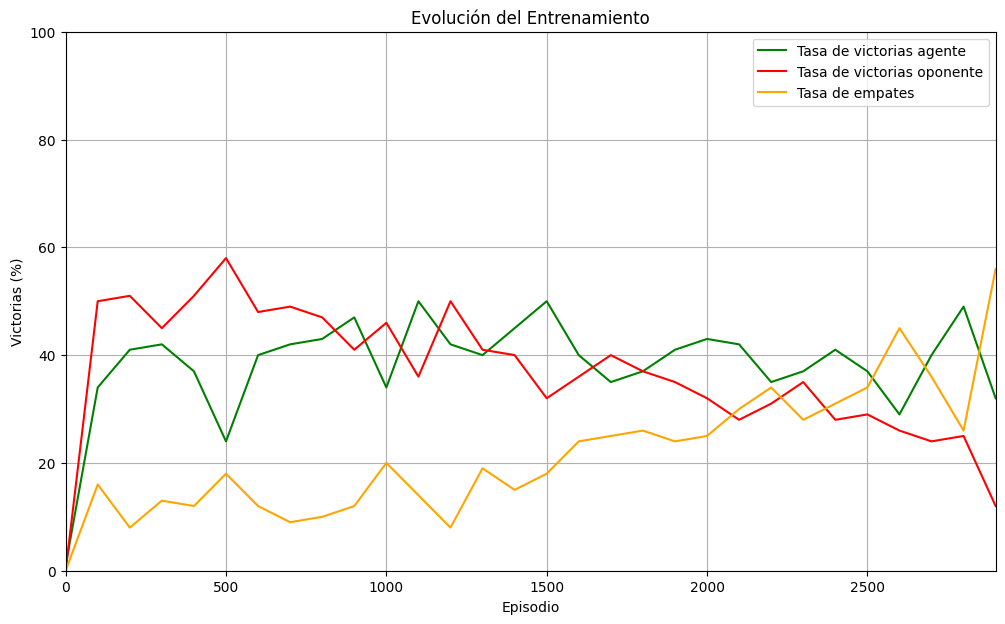

Estados acumulados en la Q-Table del agente: 621

----- ENFRENTAMIENTO IA vs MINIMAX (500 PARTIDAS) -----
ESTADÍSTICAS DEL AGENTE COMO PLAYER_1: 
Victorias = 0, Derrotas = 0, Empates = 250
ESTADÍSTICAS DEL AGENTE COMO PLAYER_2: 
Victorias = 0, Derrotas = 0, Empates = 250

Tasa de invencibilidad (Agente = Player_1): 100.00%
Tasa de invencibilidad (Agente = Player_2): 100.00%



In [77]:
def main():

    # ------ CONFIGURACIÓN DE PARÁMETROS ------
    num_episodes = 3000
    difficulty_level = 0
    start_player = 1
    user_symbol = 'X'
    gui = True

    # ENTRENAMIENTO
    agent = training(num_episodes)
    print(f"Estados acumulados en la Q-Table del agente: {len(agent.q_table)}\n")
    # print(agent.q_table)

    # INVINCIBILITY_TEST
    invincibility_test(agent, 500)

    # Se inicia el juego
    simulator = Simulator(agent, start_player, difficulty_level)
    if gui:
        root = tk.Tk()
        GUI(root, simulator, user_symbol)
        root.mainloop()
    else:
        console = Console(simulator, user_symbol)
        console.execute()

if __name__ == '__main__':
    main()

## 9. Conclusiones
Este proyecto muestra la eficacia del aprendizaje por refuerzo (RL) y el Q-learning, aplicando sus fundamentos teóricos en el desarrollo exitoso de un sistema inteligente experto en jugar al tres en raya. Su desarrollo permitió asimilar que la elección del oponente y la incertidumbre que conlleva afecta a la convergencia del aprendizaje de nuestro agente.

Se establecieron los parámetros adecuados para conseguir un proceso de entrenamiento de nuestro agente óptimo: Un factor de descuento $\gamma$ alto para centrarnos en la victoria final; así como un $\alpha$ que decrece progresivamente, permitiendo corregir errores incluso en las últimas fases del entrenamiento.

Destacan los mecanismos de optimización y generalización utilizados:
- **Reducción por simetrías**, que redujeron el espacio de estado de miles a apenas unos 620 estados únicos.
- **Selección de acciones** (epsilon-greedy-decreasing).
- **Actualización con backtracking** de la Q-table.
- **Percepción relativa** del tablero por parte de nuestro agente, que nos permite mantener un estándar sobre los estados que se guardan en la Q-table.

Con todo lo anterior se consigue una convergencia del proceso de aprendizaje más rápida y eficiente.

Si bien hoy en día se utilizan conceptos más avanzados tales como redes neuronales y aprendizaje por refuerzo profundo, este proyecto establece los cimientos sobre los que se sustentan los grandes programas de hoy en día.